# Exploratory data analysis — US large-cap equities

This notebook works through the questions that have to be answered *before* any
model or portfolio is built:

1. **Data quality** — is the panel complete, aligned and free of bad prints?
2. **Distribution shape** — are daily returns normal? (They are not, and it matters.)
3. **Cross-section** — how are return and risk spread across 60 names and 11 sectors?
4. **Co-movement** — what does the correlation structure look like, and is it stable?
5. **Regimes** — which sectors led and lagged in each market episode?
6. **Calendar effects** — is there anything in month-of-year or day-of-week?
7. **Factor screen** — do simple factors separate winners from losers?
8. **What this rules out** — the conclusions that constrain the rest of the project.

Every number here comes from the same pipeline the dashboard uses, so the
figures in this notebook and the figures in the app cannot disagree.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.pipeline import build_analytics
from src import eda
from src.visualizer import (
    CATEGORICAL, DIVERGING_RETURNS, SEQUENTIAL,
    AXIS, GRID, TEXT_PRIMARY, TEXT_SECONDARY,
)

# src.visualizer pins the Agg backend for file export; switch to inline here.
%matplotlib inline

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]

In [2]:
# One call runs ingest -> clean -> indicators -> metrics -> factors -> portfolios.
bundle = build_analytics()

returns   = bundle.returns          # 1,938 x 60 daily returns
metrics   = bundle.metrics          # 38 metrics per holding
benchmark = bundle.benchmark_returns

print(f"{len(bundle.tickers)} holdings across {metrics['Sector'].nunique()} sectors")
print(f"{bundle.start:%Y-%m-%d} -> {bundle.end:%Y-%m-%d}  ({bundle.sessions:,} sessions)")
print(f"{bundle.observations:,} price observations  |  risk-free {bundle.risk_free:.2%}")

  Loaded cached analytics (0.5h old) — 60 symbols
60 holdings across 11 sectors
2019-01-03 -> 2026-09-18  (1,938 sessions)
116,340 price observations  |  risk-free 2.73%


---
## 1. Data quality

Nothing downstream is trustworthy if the panel is not. Each symbol is checked
for duplicate dates, non-positive prices, calendar gaps and extreme moves. The
audit is produced by the pipeline itself, not reconstructed here.

In [3]:
quality = bundle.quality
print(quality[["Clean Rows", "Duplicate Dates", "Non-Positive Prices",
               "Calendar Gaps Filled", "Return Outliers (>8σ)", "Coverage (%)"]]
      .describe().loc[["mean", "min", "max"]].round(2))

print("\nTotals across the panel")
print(f"  duplicate dates removed : {int(quality['Duplicate Dates'].sum()):,}")
print(f"  non-positive prices     : {int(quality['Non-Positive Prices'].sum()):,}")
print(f"  calendar gaps filled    : {int(quality['Calendar Gaps Filled'].sum()):,}")
print(f"  8σ moves flagged        : {int(quality['Return Outliers (>8σ)'].sum()):,}")
print(f"  mean calendar coverage  : {quality['Coverage (%)'].mean():.2f}%")

      Clean Rows  Duplicate Dates  Non-Positive Prices  Calendar Gaps Filled  Return Outliers (>8σ)  Coverage (%)
mean      1939.0              0.0                  0.0                   0.0                   1.16         100.0
min       1939.0              0.0                  0.0                   0.0                   0.00         100.0
max       1939.0              0.0                  0.0                   0.0                   4.00         100.0

Totals across the panel
  duplicate dates removed : 0
  non-positive prices     : 0
  calendar gaps filled    : 0
  8σ moves flagged        : 71
  mean calendar coverage  : 100.00%


Extreme returns are **flagged, not removed**. Real markets gap — an earnings
surprise or a policy shock genuinely produces an 8σ day. Winsorising them would
make every risk metric in this project look better than reality.

---
## 2. Distribution shape — returns are not normal

Most textbook risk maths assumes normally distributed returns. This is the
single most consequential assumption to test, because if it fails, variance
alone understates the risk of loss.

In [4]:
dist = eda.distribution_table(returns)
tails = eda.fat_tail_summary(returns)

print(f"Symbols tested                 : {tails['symbols']}")
print(f"Normal at 5% (Jarque-Bera)     : {tails['normal_at_5pct']}")
print(f"Mean excess kurtosis           : {tails['mean_excess_kurtosis']:.2f}   (normal = 0)")
print(f"Share with negative skew       : {tails['mean_negative_skew']:.0%}")
print(f"±3σ days observed              : {tails['observed_3sigma_days']:,}")
print(f"±3σ days a normal would predict   : {tails['expected_3sigma_days']:.0f}")
print(f"Ratio                          : "
      f"{tails['observed_3sigma_days'] / tails['expected_3sigma_days']:.1f}x")

dist.sort_values("Excess Kurtosis", ascending=False).head(8).round(3)

Symbols tested                 : 60
Normal at 5% (Jarque-Bera)     : 0
Mean excess kurtosis           : 11.28   (normal = 0)
Share with negative skew       : 40%
±3σ days observed              : 1,765
±3σ days a normal would predict   : 312
Ratio                          : 5.7x


,Sector,Mean (bps/day),Std (bps/day),Skew,Excess Kurtosis,Jarque-Bera p,Normal at 5%,Days beyond ±3σ,Expected beyond ±3σ
Ticker,,,,,,,,,
MCD,Consumer Discretionary,3.633,135.701,0.334,31.410,0.0,False,25,5.2
ORCL,Information Technology,9.708,248.961,2.040,29.260,0.0,False,30,5.2
SO,Utilities,6.106,148.215,0.803,24.098,0.0,False,23,5.2
CVX,Energy,7.027,199.396,-0.332,23.183,0.0,False,26,5.2
NFLX,Communication Services,8.718,265.709,-1.003,21.482,0.0,False,33,5.2
UNH,Health Care,5.143,207.144,-1.371,20.594,0.0,False,35,5.2
SBUX,Consumer Discretionary,4.931,200.776,0.886,20.478,0.0,False,28,5.2
LOW,Consumer Discretionary,6.423,192.301,-1.098,19.638,0.0,False,20,5.2


findfont: Failed to find font weight 600 for Helvetica Neue, now using 700.


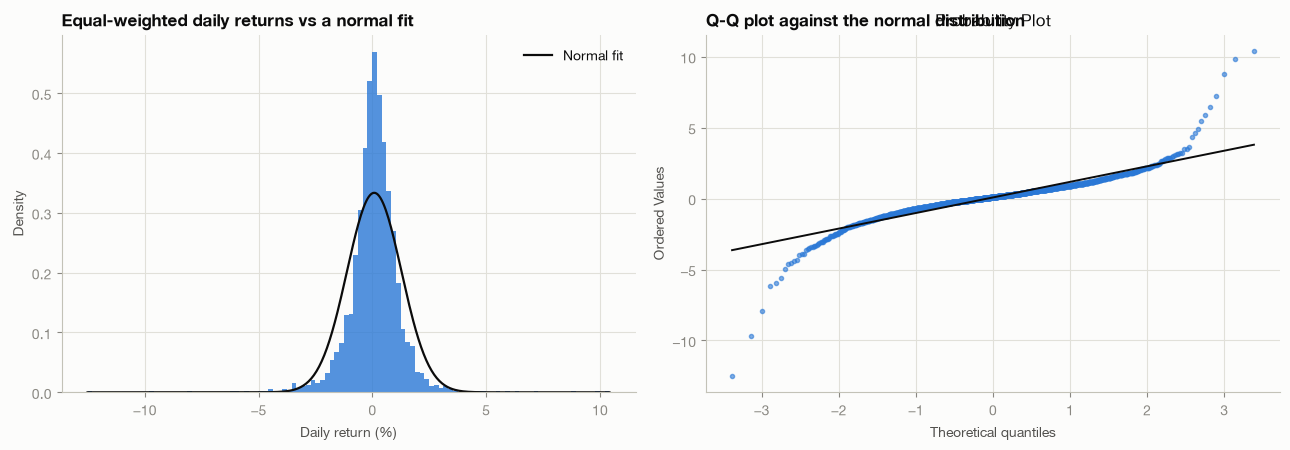

In [5]:
equal_weighted = returns.mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.hist(equal_weighted, bins=110, color=BLUE, alpha=0.8, density=True)
grid = np.linspace(equal_weighted.min(), equal_weighted.max(), 400)
mu, sigma = equal_weighted.mean(), equal_weighted.std()
ax.plot(grid, stats.norm.pdf(grid, mu, sigma), color=TEXT_PRIMARY, lw=1.6,
        label="Normal fit")
ax.set_title("Equal-weighted daily returns vs a normal fit", loc="left",
             fontsize=12, fontweight="600")
ax.set_xlabel("Daily return (%)"); ax.set_ylabel("Density")
ax.legend(frameon=False)

# A Q-Q plot makes the tails explicit in a way a histogram cannot.
ax = axes[1]
stats.probplot(equal_weighted, dist="norm", plot=ax)
ax.get_lines()[0].set(color=BLUE, marker="o", markersize=3, alpha=0.6)
ax.get_lines()[1].set(color=TEXT_PRIMARY, lw=1.4)
ax.set_title("Q-Q plot against the normal distribution", loc="left",
             fontsize=12, fontweight="600")

for ax in axes:
    ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

The Q-Q plot is the clearest statement of the problem: the points bend away
from the line at both ends, so the largest moves — in both directions — are far
more frequent and far larger than a normal distribution allows.

**Consequence for this project:** Value at Risk is computed *historically*
(reading the empirical distribution) rather than parametrically, and expected
shortfall is reported alongside it.

---
## 3. The cross-section

Where does return and risk actually sit across 60 names?

In [6]:
summary = metrics[["CAGR", "Volatility", "Sharpe", "Max Drawdown", "Beta",
                   "Hit Rate", "Excess Kurtosis"]].describe().T
summary[["mean", "50%", "std", "min", "max"]].round(3)

,mean,50%,std,min,max
CAGR,0.164,0.137,0.138,-0.077,0.722
Volatility,0.320,0.306,0.091,0.193,0.629
Sharpe,0.416,0.415,0.329,-0.303,1.376
Max Drawdown,-0.487,-0.443,0.148,-0.781,-0.238
Beta,0.960,0.989,0.339,0.400,1.829
Hit Rate,0.522,0.524,0.013,0.486,0.542
Excess Kurtosis,11.277,9.820,6.160,3.787,31.410


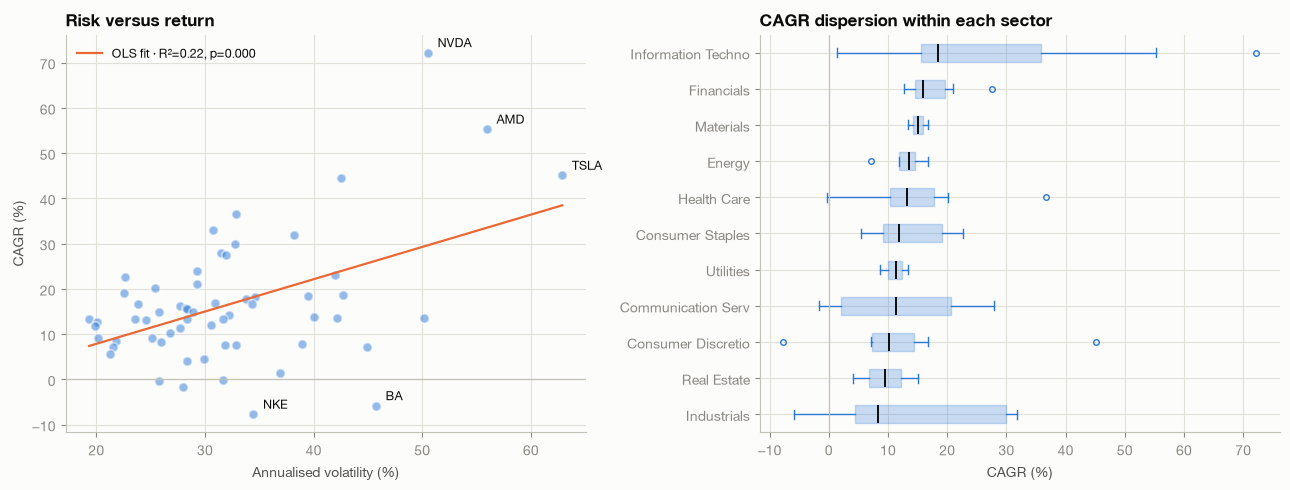

Risk-return regression: slope=0.71, R²=0.222, p=0.0001


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(metrics["Volatility"] * 100, metrics["CAGR"] * 100,
           s=46, color=BLUE, alpha=0.5, edgecolors="white", linewidths=1.4)
for ticker in set(metrics.nlargest(3, "CAGR").index) | set(metrics.nsmallest(2, "CAGR").index):
    ax.annotate(ticker, (metrics.loc[ticker, "Volatility"] * 100,
                         metrics.loc[ticker, "CAGR"] * 100),
                xytext=(7, 4), textcoords="offset points", fontsize=9)
ax.axhline(0, color=AXIS, lw=0.9)
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("CAGR (%)")
ax.set_title("Risk versus return", loc="left", fontsize=12, fontweight="600")

# Does taking more risk actually pay over this window?
slope, intercept, r, p, _ = stats.linregress(metrics["Volatility"], metrics["CAGR"])
xs = np.linspace(metrics["Volatility"].min(), metrics["Volatility"].max(), 50)
ax.plot(xs * 100, (intercept + slope * xs) * 100, color=ORANGE, lw=1.6,
        label=f"OLS fit · R²={r**2:.2f}, p={p:.3f}")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
order = metrics.groupby("Sector")["CAGR"].median().sort_values().index
ax.boxplot([metrics.loc[metrics["Sector"] == s, "CAGR"] * 100 for s in order],
           tick_labels=[s[:18] for s in order], vert=False,
           patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.25, edgecolor=BLUE),
           medianprops=dict(color=TEXT_PRIMARY, lw=1.4),
           whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
           flierprops=dict(markeredgecolor=BLUE, markersize=4))
ax.axvline(0, color=AXIS, lw=0.9)
ax.set_xlabel("CAGR (%)")
ax.set_title("CAGR dispersion within each sector", loc="left", fontsize=12, fontweight="600")

for ax in axes:
    ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
    for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Risk-return regression: slope={slope:.2f}, R²={r**2:.3f}, p={p:.4f}")

The spread **inside** most sectors is wider than the spread **between** sector
averages. Sector allocation alone therefore explains less of the outcome than
name selection does — which is why the dashboard keeps both views.

---
## 4. Co-movement

Correlation decides whether a basket of holdings is actually diversified.

In [8]:
corr = returns.corr()
off_diagonal = corr.values[np.triu_indices_from(corr.values, k=1)]

print(f"Mean pairwise correlation   : {off_diagonal.mean():.3f}")
print(f"Median                      : {np.median(off_diagonal):.3f}")
print(f"Range                       : {off_diagonal.min():.2f} to {off_diagonal.max():.2f}")
print(f"Pairs above 0.70            : {(off_diagonal > 0.70).sum()} "
      f"of {len(off_diagonal)}")
print(f"Pairs below 0.20            : {(off_diagonal < 0.20).sum()}")

sector_corr = eda.sector_correlation(returns)
print("\nSector-level correlation (equal-weighted sector series)")
print(sector_corr.round(2))

Mean pairwise correlation   : 0.347
Median                      : 0.342
Range                       : 0.04 to 0.90
Pairs above 0.70            : 17 of 1770
Pairs below 0.20            : 226

Sector-level correlation (equal-weighted sector series)
                        Communication Services  Consumer Discretionary  Consumer Staples  Energy  Financials  Health Care  Industrials  Information Technology  Materials  Real Estate  Utilities
Communication Services                    1.00                    0.73              0.52    0.38        0.68         0.46         0.61                    0.72       0.58         0.49       0.39
Consumer Discretionary                    0.73                    1.00              0.55    0.40        0.70         0.49         0.66                    0.75       0.69         0.57       0.42
Consumer Staples                          0.52                    0.55              1.00    0.28        0.51         0.61         0.45                    0.44       0.61  

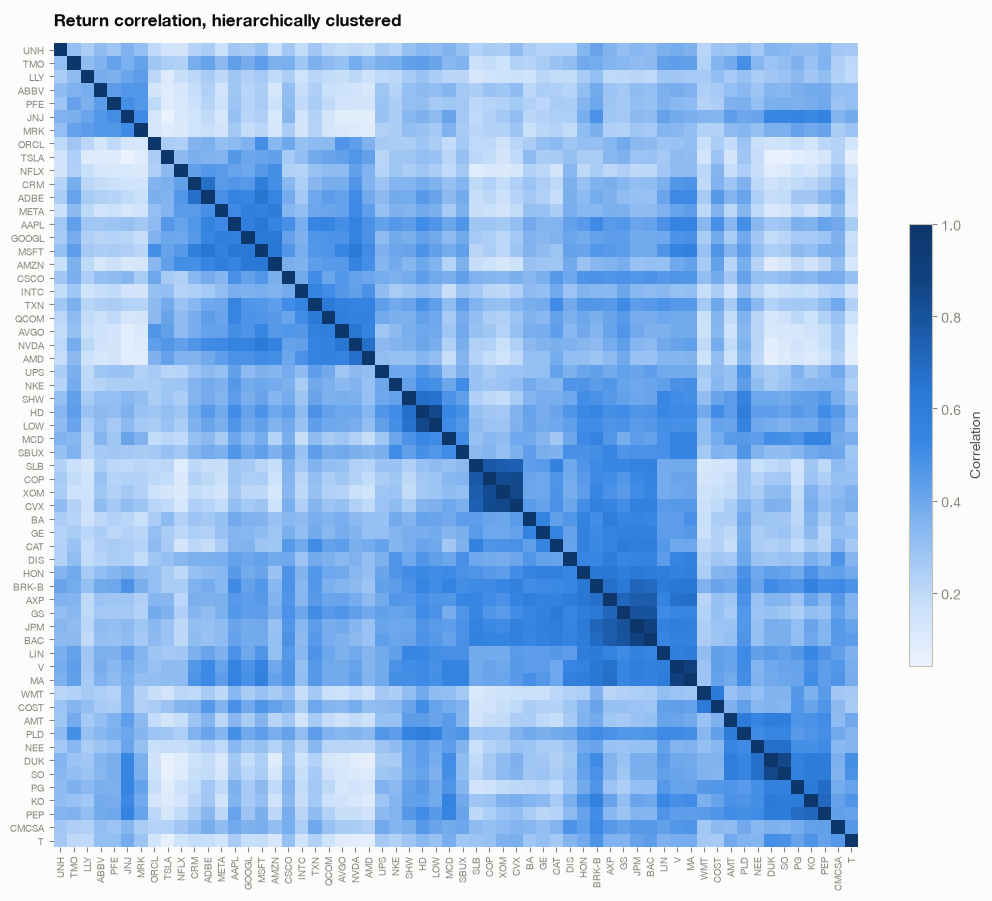

In [9]:
# Hierarchical clustering makes the block structure visible.
order = eda.cluster_order(corr)
clustered = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(clustered.values, cmap=SEQUENTIAL,
                  vmin=max(0, clustered.values.min()), vmax=1)
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=7)
ax.set_yticks(range(len(order)), order, fontsize=7)
ax.set_title("Return correlation, hierarchically clustered", loc="left",
             fontsize=12, fontweight="600", pad=12)
bar = fig.colorbar(image, ax=ax, shrink=0.55); bar.set_label("Correlation")
ax.grid(False)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout(); plt.show()

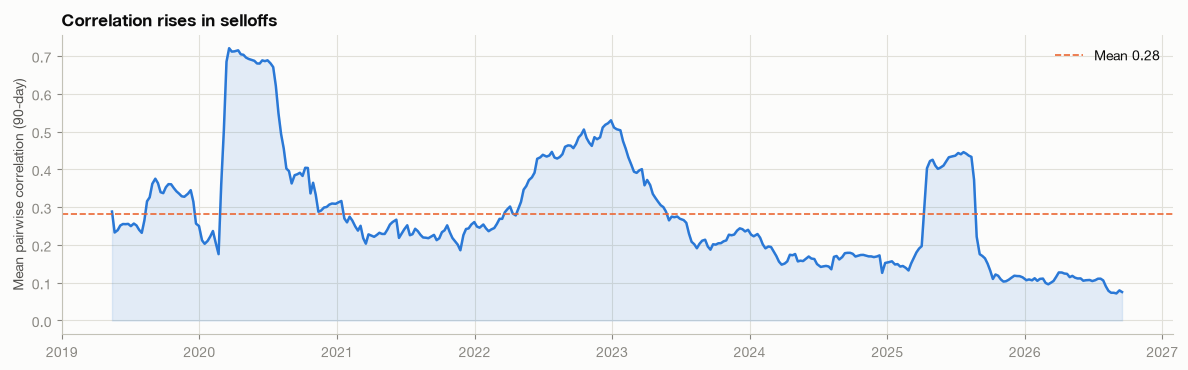

Mean correlation, COVID crash window : 0.641
Mean correlation, rest of the sample : 0.263


In [10]:
# Is the correlation structure stable? Diversification is only useful if it
# holds up when it is needed.
rolling = eda.average_pairwise_correlation(returns, window=90)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(rolling.index, rolling.values, color=BLUE, lw=1.8)
ax.fill_between(rolling.index, rolling.values, alpha=0.12, color=BLUE)
ax.axhline(rolling.mean(), color=ORANGE, lw=1.2, ls="--",
           label=f"Mean {rolling.mean():.2f}")
ax.set_ylabel("Mean pairwise correlation (90-day)")
ax.set_title("Correlation rises in selloffs", loc="left", fontsize=12, fontweight="600")
ax.legend(frameon=False)
ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

crisis = rolling.loc["2020-02-20":"2020-06-30"]
calm = rolling.drop(crisis.index)
print(f"Mean correlation, COVID crash window : {crisis.mean():.3f}")
print(f"Mean correlation, rest of the sample : {calm.mean():.3f}")

Correlation spikes precisely during the drawdowns it is supposed to protect
against. This is the standard argument for judging a portfolio on its
drawdown and expected shortfall rather than on its average correlation.

---
## 5. Market regimes

Averages over seven years hide the fact that leadership rotates completely
between episodes.

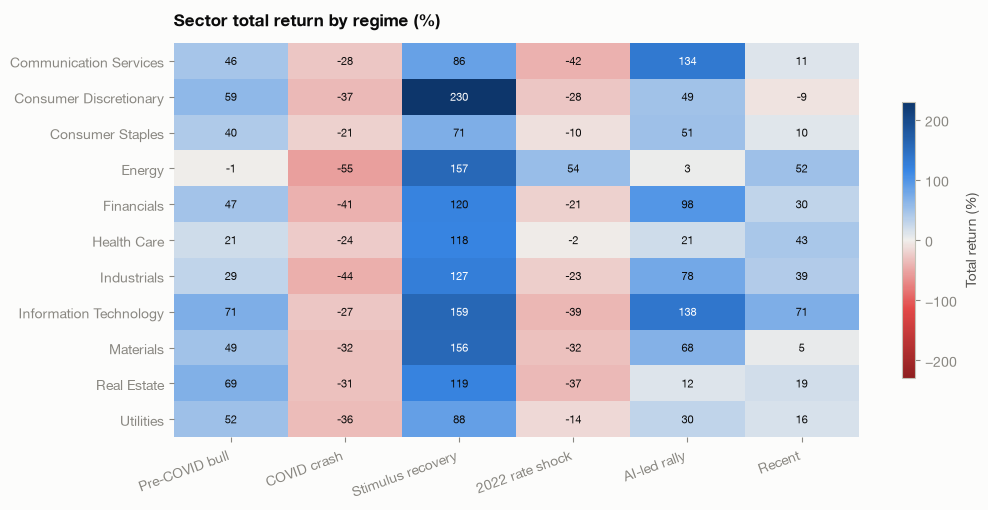

Leader and laggard in each regime
  Pre-COVID bull       best Information Technology      70.8%   worst Energy                      -0.9%
  COVID crash          best Consumer Staples           -20.6%   worst Energy                     -54.9%
  Stimulus recovery    best Consumer Discretionary     229.6%   worst Consumer Staples            71.2%
  2022 rate shock      best Energy                      54.4%   worst Communication Services     -42.4%
  AI-led rally         best Information Technology     138.1%   worst Energy                       2.7%
  Recent               best Information Technology      70.9%   worst Consumer Discretionary      -8.9%


In [11]:
regimes = eda.regime_matrix(returns) * 100

fig, ax = plt.subplots(figsize=(10.5, 5.2))
limit = np.nanmax(np.abs(regimes.values))
image = ax.imshow(regimes.values, cmap=DIVERGING_RETURNS,
                  vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(len(regimes.columns)), regimes.columns, rotation=20, ha="right")
ax.set_yticks(range(len(regimes.index)), regimes.index)
for i in range(regimes.shape[0]):
    for j in range(regimes.shape[1]):
        value = regimes.values[i, j]
        if np.isnan(value): continue
        ink = "white" if abs(value) > limit * 0.55 else TEXT_PRIMARY
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=8, color=ink)
ax.set_title("Sector total return by regime (%)", loc="left",
             fontsize=12, fontweight="600", pad=12)
fig.colorbar(image, ax=ax, shrink=0.7).set_label("Total return (%)")
ax.grid(False)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout(); plt.show()

print("Leader and laggard in each regime")
for regime in regimes.columns:
    column = regimes[regime].dropna()
    print(f"  {regime:<20} best {column.idxmax():<24} {column.max():>7.1f}%"
          f"   worst {column.idxmin():<24} {column.min():>7.1f}%")

The 2022 rate shock is the clearest illustration: Energy was the only sector
with a materially positive return while Information Technology and
Communication Services fell ~40%. A backtest run only on the post-2022 window
would reach the opposite conclusion about both.

---
## 6. Calendar effects

Seasonality claims are common and mostly noise. This tests two of them properly.

In [12]:
weekday = eda.day_of_week_effect(returns)
print("Day-of-week effect (one-sample t-test against zero)")
print(weekday.round(4))
print(f"\nWeekdays significant at 5%: "
      f"{weekday.index[weekday['Significant at 5%']].tolist() or 'none'}")
print("With five tests at the 5% level, ~0.25 false positives are expected by chance.")

Day-of-week effect (one-sample t-test against zero)
           Mean (bps)  Positive Share  Observations  t-stat  p-value  Significant at 5%
Weekday                                                                                
Monday         9.7666          0.5801           362  1.4376   0.1514              False
Tuesday        8.5272          0.5062           401  1.5254   0.1280              False
Wednesday      7.9272          0.5668           397  1.3660   0.1727              False
Thursday       3.6625          0.5641           390  0.5883   0.5566              False
Friday        10.2570          0.5799           388  1.6962   0.0906              False

Weekdays significant at 5%: none
With five tests at the 5% level, ~0.25 false positives are expected by chance.


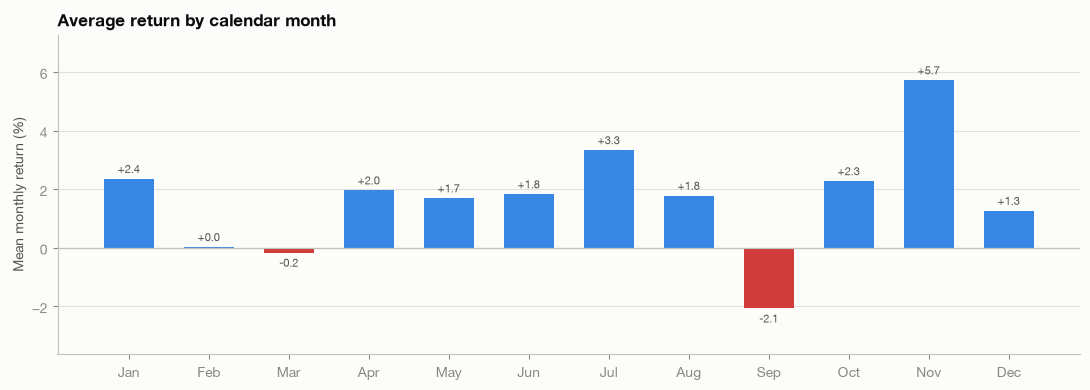

In [13]:
seasonal = eda.monthly_seasonality(returns).mean(axis=1) * 100

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#3987e5" if v >= 0 else "#d03b3b" for v in seasonal.values]
ax.bar(seasonal.index, seasonal.values, color=colors, width=0.62)
ax.axhline(0, color=AXIS, lw=0.9)
for month, value in seasonal.items():
    ax.text(month, value + (0.12 if value >= 0 else -0.12), f"{value:+.1f}",
            ha="center", va="bottom" if value >= 0 else "top", fontsize=8,
            color=TEXT_SECONDARY)
ax.set_ylabel("Mean monthly return (%)")
ax.set_title("Average return by calendar month", loc="left", fontsize=12, fontweight="600")
ax.grid(axis="y", color=GRID, lw=0.8); ax.set_axisbelow(True)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
ax.margins(y=0.2)
plt.tight_layout(); plt.show()

In [14]:
# Is September genuinely different, or is this a small-sample artefact?
monthly = (1 + returns.mean(axis=1)).resample("ME").prod() - 1
september = monthly[monthly.index.month == 9]
others = monthly[monthly.index.month != 9]
t_stat, p_value = stats.ttest_ind(september, others, equal_var=False)

print(f"September mean {september.mean()*100:+.2f}% (n={len(september)}) vs "
      f"{others.mean()*100:+.2f}% for other months")
print(f"Welch t-test: t={t_stat:.2f}, p={p_value:.3f}")

# September was singled out *because* it looked worst, and it is one of twelve
# months that could have been tested. Correcting for that is the honest check.
bonferroni = 0.05 / 12
print(f"\nUncorrected 5% threshold      : 0.050  -> "
      f"{'reject' if p_value < 0.05 else 'retain'} the null")
print(f"Bonferroni threshold (12 tests): {bonferroni:.4f}  -> "
      f"{'reject' if p_value < bonferroni else 'retain'} the null")
print(f"Sample size: {len(september)} Septembers — one bad month moves this a lot.")

September mean -2.04% (n=8) vs +1.99% for other months
Welch t-test: t=-2.58, p=0.031

Uncorrected 5% threshold      : 0.050  -> reject the null
Bonferroni threshold (12 tests): 0.0042  -> retain the null
Sample size: 8 Septembers — one bad month moves this a lot.


The September pattern is visible in the averages but does not survive a
significance test on this sample. Treating it as tradable would be reading
noise.

---
## 7. Factor screen

Four factors, z-scored across the cross-section and blended into a composite:
12-1 momentum, risk-adjusted return, low volatility, and drawdown resilience.

In [15]:
factors = bundle.factors
print("Top 10 by composite score")
print(factors[["Sector", "Momentum 12-1", "Sharpe", "Volatility",
               "Composite Score", "Rank"]].head(10).round(3))

print("\nBottom 5")
print(factors[["Sector", "Composite Score", "Rank"]].tail(5).round(3))

Top 10 by composite score
                        Sector  Momentum 12-1  Sharpe  Volatility  Composite Score  Rank
Ticker                                                                                  
LLY                Health Care          0.695   1.031       0.329            1.027     1
JNJ                Health Care          0.570   0.546       0.193            0.903     2
CAT                Industrials          0.827   0.830       0.327            0.872     3
AAPL    Information Technology          0.331   0.984       0.307            0.827     4
COST          Consumer Staples         -0.000   0.885       0.226            0.741     5
WMT           Consumer Staples          0.103   0.725       0.225            0.736     6
MRK                Health Care          0.920   0.422       0.246            0.667     7
AMD     Information Technology          1.931   0.940       0.559            0.628     8
ABBV               Health Care          0.242   0.683       0.254            0.606  

In [16]:
# Does the composite score have any relationship with the outcome it is
# supposed to rank? Correlating it against realised metrics is the sanity check.
joined = factors.join(metrics[["CAGR", "Sharpe", "Max Drawdown"]], rsuffix="_m")
checks = {
    "Composite vs CAGR":         stats.spearmanr(joined["Composite Score"], joined["CAGR"]),
    "Composite vs Sharpe":       stats.spearmanr(joined["Composite Score"], joined["Sharpe_m"]),
    "Composite vs Max Drawdown": stats.spearmanr(joined["Composite Score"], joined["Max Drawdown_m"]),
}
for label, result in checks.items():
    print(f"  {label:<28} Spearman ρ={result.statistic:+.3f}  p={result.pvalue:.4f}")

  Composite vs CAGR            Spearman ρ=+0.529  p=0.0000
  Composite vs Sharpe          Spearman ρ=+0.755  p=0.0000
  Composite vs Max Drawdown    Spearman ρ=+0.749  p=0.0000


These correlations are measured **in-sample** — the factors are built from the
same window the outcomes are measured over, so a positive relationship is
partly mechanical. The screen is presented as a descriptive ranking tool, not
as evidence of predictive power.

---
## 8. Do technical rules beat holding the stock?

Three classic rules, run across all 60 holdings. Signals are generated at each
close and traded at the next close; turnover costs 5 bps per side.

In [17]:
scan = bundle.strategy_scan
print(scan.round(3))

hold = scan.loc["Buy & Hold", "Mean Sharpe"]
print(f"\nBuy & hold mean Sharpe: {hold:.2f}")
for rule in scan.drop(index='Buy & Hold').index:
    row = scan.loc[rule]
    print(f"  {rule:<24} Sharpe {row['Mean Sharpe']:.2f}  "
          f"beats hold on {row['Win Rate vs Hold']:.0%} of holdings")

                      Mean CAGR  Median CAGR  Mean Sharpe  Mean Max Drawdown  Win Rate vs Hold
Strategy                                                                                      
Buy & Hold                0.164        0.137        0.416             -0.487             0.000
SMA 50/200 Crossover      0.077        0.041        0.140             -0.414             0.100
RSI Mean Reversion        0.046        0.051        0.121             -0.329             0.183
Trend + MACD              0.041        0.027        0.012             -0.310             0.167

Buy & hold mean Sharpe: 0.42
  SMA 50/200 Crossover     Sharpe 0.14  beats hold on 10% of holdings
  RSI Mean Reversion       Sharpe 0.12  beats hold on 18% of holdings
  Trend + MACD             Sharpe 0.01  beats hold on 17% of holdings


None of the three rules beats buy-and-hold on average, and each wins on fewer
than a quarter of the holdings. They do reduce drawdown — by sitting in cash
during selloffs — but they give up more return than the risk they remove.

This is a negative result, and it is the honest one. It is reported on the
dashboard's Strategy lab page rather than quietly dropped.

---
## 9. Portfolio construction

If rules do not add value, does allocation?

In [18]:
print(bundle.portfolios[["CAGR", "Volatility", "Sharpe", "Sortino",
                         "Max Drawdown", "Beta", "Alpha",
                         "Information Ratio"]].round(3))

                     CAGR  Volatility  Sharpe  Sortino  Max Drawdown   Beta  Alpha  Information Ratio
Strategy                                                                                             
Equal Weight        0.202       0.189   0.927    0.877        -0.330  0.954  0.031              0.688
Inverse Volatility  0.182       0.177   0.876    0.833        -0.320  0.881  0.023              0.176
Minimum Variance    0.155       0.144   0.884    0.855        -0.237  0.574  0.041             -0.144
Maximum Sharpe      0.403       0.211   1.776    1.704        -0.279  0.960  0.190              2.244
Benchmark (SPY)     0.173       0.193   0.754    0.714        -0.337  1.000  0.000              0.000


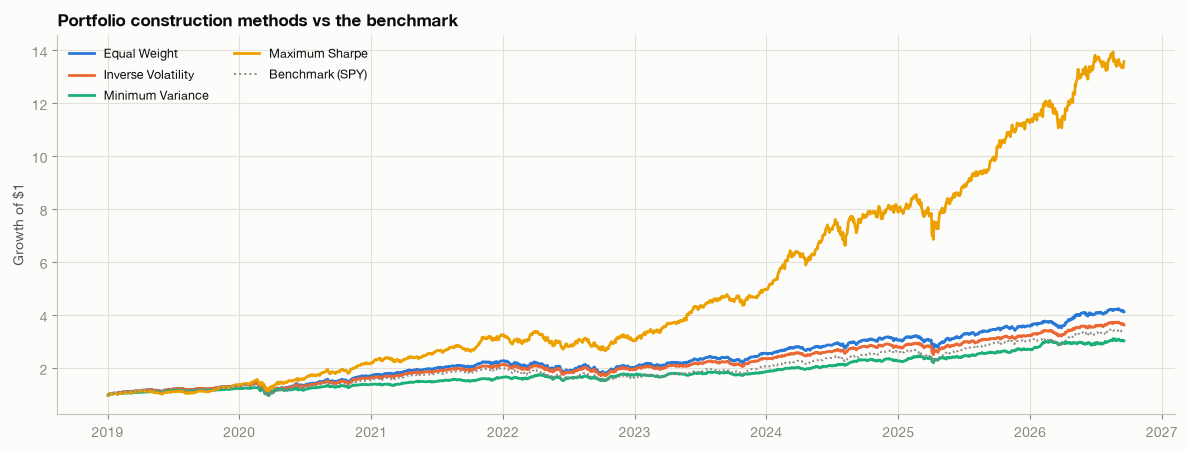

In [19]:
fig, ax = plt.subplots(figsize=(12, 4.6))
for slot, (name, series) in enumerate(bundle.portfolio_curves.items()):
    growth = (1 + series.fillna(0)).cumprod()
    is_benchmark = "Benchmark" in name
    ax.plot(growth.index, growth.values,
            color="#898781" if is_benchmark else CATEGORICAL[slot],
            lw=1.4 if is_benchmark else 2.0,
            ls=":" if is_benchmark else "-", label=name)
ax.set_ylabel("Growth of $1")
ax.set_title("Portfolio construction methods vs the benchmark", loc="left",
             fontsize=12, fontweight="600")
ax.legend(frameon=False, ncol=2, fontsize=9)
ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
for spine in ("top", "right"): ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

Equal weight beats the cap-weighted benchmark on Sharpe without any forecast at
all — a small-cap-within-large-cap tilt plus the rebalancing premium.

The maximum-Sharpe portfolio looks spectacular, and that number should be
distrusted: its weights are chosen using the same returns it is then scored on.
Equal weight and inverse volatility require no return forecast and are the fair
comparison.

---
## Conclusions

| Question | Finding | What it changes |
|---|---|---|
| Are returns normal? | No — all 60 reject Jarque-Bera; ±3σ days are 5.7× too frequent | Use historical VaR and expected shortfall, not parametric |
| Is the universe diversified? | Mean pairwise ρ 0.35, rising sharply in selloffs | Judge portfolios on drawdown, not average correlation |
| Sector or stock selection? | Within-sector spread exceeds between-sector spread | Keep name-level views, not just sector roll-ups |
| Do calendar effects exist? | September is weak (p=0.03) but fails Bonferroni correction on 8 observations | Do not trade it |
| Do technical rules work? | None beats buy-and-hold across 60 names | Report the negative result |
| Does allocation work? | Equal weight beats the benchmark on Sharpe with no forecast | Prefer forecast-free construction |

Every figure above is reproducible with `python main.py` and explorable
interactively with `python dashboard.py`.